In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [3]:
tab2 = Table.read("C:/Users/Ruben/Documents/Bachelorarbeit/All_candidates.vot")

In [4]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m


dist_pc2 = r_from_plx(np.array(tab2["parallax"])) # in pc
r_pc2 = dist_pc2 * np.cos(np.array(tab2["b"])*deg2rad) # in pc
z_pc2 = dist_pc2 * np.sin(np.array(tab2["b"])*deg2rad) +14.5 #correction for height of the sun above the galactic plane
apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"])
absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5
teff2 = np.array(tab2["teff_gspphot"]) # in K
g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag

print('Anzahl Sterne gesamt: ', len(tab2))
print('Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude: ', len(tab2[np.isnan(absolute_magnitude2)]), ' vernachlässigbar')
absmag = (absolute_magnitude2 >= 5) & (absolute_magnitude2 <= 8)
print('Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag: ', len(tab2[absmag]))
print('davon ohne Teff: ', len(tab2[absmag][np.isnan(teff2[absmag])]))
print('davon mit richtiger Teff: ', len(tab2[absmag][(teff2[absmag]>=4000)&(teff2[absmag]<=5000)]), ' ungefähr alle aus der anderen Query')
print('davon ohne z: ', len(tab2[absmag][np.isnan(z_pc2[absmag])]))
print('davon ohne bp_rp: ', len(tab2[absmag][np.isnan(bp_rp2[absmag])]), ' vernachlässigbar')
print('davon ohne bp_g: ', len(tab2[absmag][np.isnan(bp_g2[absmag])]), ' vernachlässigbar')
print('davon ohne g_rp: ', len(tab2[absmag][np.isnan(g_rp2[absmag])]), ' vernachlässigbar')
print('davon im kleinen Zylinder: ', len(tab2[absmag&(r_pc2<100)]))

Anzahl Sterne gesamt:  9801080
Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude:  19848  vernachlässigbar
Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag:  968550
davon ohne Teff:  155387
davon mit richtiger Teff:  545857  ungefähr alle aus der anderen Query
davon ohne z:  0
davon ohne bp_rp:  8153  vernachlässigbar
davon ohne bp_g:  8107  vernachlässigbar
davon ohne g_rp:  8106  vernachlässigbar
davon im kleinen Zylinder:  241863


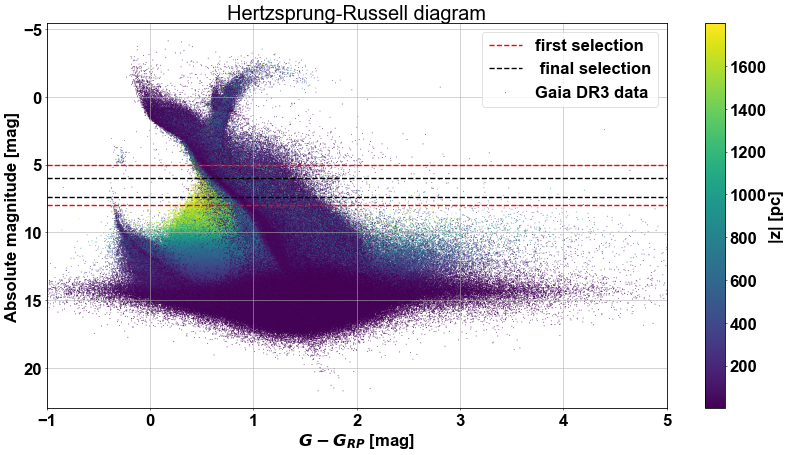

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
scatter = ax[0].scatter(g_rp2[np.where(abs(z_pc2)<=1800)], absolute_magnitude2[np.where(abs(z_pc2)<=1800)], c=np.abs(z_pc2)[np.where(abs(z_pc2)<=1800)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('hr.png')
fig.set_dpi(50)
plt.show()

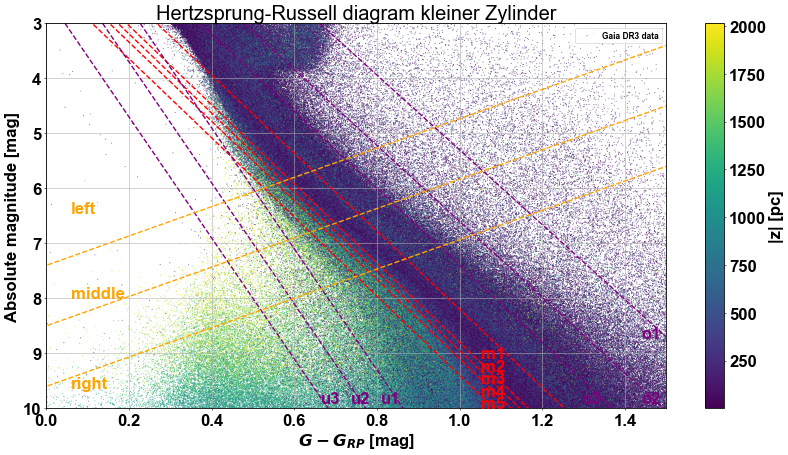

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
r = 200

scatter = ax[0].scatter(g_rp2[(r_pc2<r)], absolute_magnitude2[(r_pc2<r)], c=np.abs(z_pc2)[(r_pc2<r)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

x = np.array([-1,5])

ax[0].plot(x, 6.8*x-1.5, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 6.9*x-0.3, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 7.0*x+0.4, color='purple', linestyle='--', linewidth=2)

ax[0].plot(x, 7.1*x+1.1, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 7.2*x+1.6, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 7.2*x+1.75, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 7.2*x+1.9, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, 7.2*x+2.2, color='red', linestyle='--', linewidth=2)

ax[0].plot(x, 11*x+0.5, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 11*x+1.5, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, 11*x+2.5, color='purple', linestyle='--', linewidth=2)


ax[0].plot(x, 8 * (-1/3) * x + 7.4, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 9.6, color='orange', linestyle='--', linewidth=2)
ax[0].plot(x, 8 * (-1/3) * x + 8.5, color='orange', linestyle='--', linewidth=2)



ax[0].grid()
ax[0].legend(loc='upper right', fontsize='12')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram kleiner Zylinder')
ax[0].invert_yaxis()
# ax[0].set_xlim(-0, 3)
# ax[0].set_ylim(8, 5)
ax[0].set_xlim(-0.0, 1.5)
ax[0].set_ylim(10, 3)
plt.figtext(0.4, 0.12, 'u3', color='purple')
plt.figtext(0.43, 0.12, 'u2', color='purple')
plt.figtext(0.46, 0.12, 'u1', color='purple')

plt.figtext(0.15, 0.5, 'left', color='orange')
plt.figtext(0.15, 0.33, 'middle', color='orange')
plt.figtext(0.15, 0.15, 'right', color='orange')

plt.figtext(0.72, 0.25, 'o1', color='purple')
plt.figtext(0.72, 0.12, 'o2', color='purple')
plt.figtext(0.66, 0.12, 'o3', color='purple')

plt.figtext(0.56, 0.21, 'm1', color='red')
plt.figtext(0.56, 0.185, 'm2', color='red')
plt.figtext(0.56, 0.16, 'm3', color='red')
plt.figtext(0.56, 0.135, 'm4', color='red')
plt.figtext(0.56, 0.11, 'm5', color='red')

colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('hr_colour_zoom.png')
fig.set_dpi(50)
plt.show()

In [33]:
aa = (absolute_magnitude2>=6.0)&(absolute_magnitude2<=7.4)
rr = r_pc2<200

In [34]:
r = r_pc2<200

x = g_rp2

o1 = 6.8*x-1.5
o2 = 6.9*x-0.3
o3 = 7.0*x+0.4

m1 = 7.1*x+1.1
m2 = 7.2*x+1.6
m3 = 7.2*x+1.75
m4 = 7.2*x+1.9
m5 = 7.2*x+2.2

u1 = 11*x+0.5
u2 = 11*x+1.5
u3 = 11*x+2.5

left = 8 * (-1/3) * x + 7.4
right = 8 * (-1/3) * x + 9.6
middle = 8 * (-1/3) * x + 8.5

''' Spezielle Cuts '''
n33, bins33 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n34, bins34 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n35, bins35 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n37, bins37 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n38, bins38 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n39, bins39 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n41, bins41 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n42, bins42 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n43, bins43 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n45, bins45 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n46, bins46 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n47, bins47 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n48, bins48 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n49, bins49 = np.histogram(z_pc2[r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m5)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n50, bins50 = np.histogram(z_pc2[r&(absolute_magnitude2>=o2)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n51, bins51 = np.histogram(z_pc2[r&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n52, bins52 = np.histogram(z_pc2[r&(absolute_magnitude2>=u1)&(absolute_magnitude2<=u3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n53, bins53 = np.histogram(z_pc2[r&(absolute_magnitude2>=m5)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n54, bins54 = np.histogram(z_pc2[r&(absolute_magnitude2>=m4)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n55, bins55 = np.histogram(z_pc2[r&(absolute_magnitude2>=m3)&(absolute_magnitude2<=u1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)



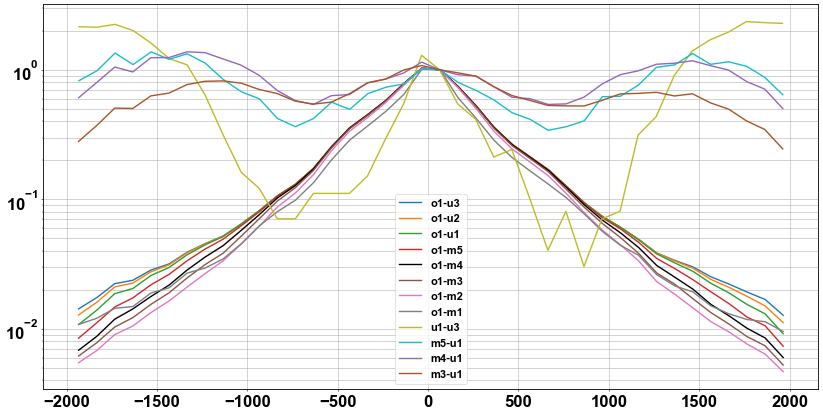

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
colors = [
    "#1f77b4",  # Blau (Blue)
    "#ff7f0e",  # Orange
    "#2ca02c",  # Grün (Green)
    "#d62728",  # Rot (Red)
    "k",  
    "#8c564b",  # Braun (Brown)
    "#e377c2",  # Rosa (Pink)
    "#7f7f7f",  # Grau (Gray)
    "#bcbd22",  # Gelbgrün (Yellow-green)
    "#17becf",  # Cyan
    "#9467bd",  # Lila (Purple)
    "#a65628",  # Dunkelbraun (Dark Brown)
    "#999999",  # Hellgrau (Light Gray)
    "#ff1493"   # Tiefes Pink (Deep Pink)
    ]
ax.plot((bins35[:-1]+bins35[1:])/2, n35/n35[20], label='o1-u3', color=colors[0])
ax.plot((bins34[:-1]+bins34[1:])/2, n34/n34[20], label='o1-u2', color=colors[1])
ax.plot((bins33[:-1]+bins33[1:])/2, n33/n33[20], label='o1-u1', color=colors[2])

# ax.plot((bins39[:-1]+bins39[1:])/2, n39/n39[20], label='o2-u3')
# ax.plot((bins38[:-1]+bins38[1:])/2, n38/n38[20], label='o2-u2')
# ax.plot((bins37[:-1]+bins37[1:])/2, n37/n37[20], label='o2-u1')

# ax.plot((bins43[:-1]+bins43[1:])/2, n43/n43[20], label='o1-u3')
# ax.plot((bins42[:-1]+bins42[1:])/2, n42/n42[20], label='o1-u2')
# ax.plot((bins41[:-1]+bins41[1:])/2, n41/n41[20], label='o1-u1')

ax.plot((bins49[:-1]+bins49[1:])/2, n49/n49[20], label='o1-m5', color=colors[3])
ax.plot((bins48[:-1]+bins48[1:])/2, n48/n48[20], label='o1-m4', color=colors[4])
ax.plot((bins47[:-1]+bins47[1:])/2, n47/n47[20], label='o1-m3', color=colors[5])
ax.plot((bins46[:-1]+bins46[1:])/2, n46/n46[20], label='o1-m2', color=colors[6])
ax.plot((bins45[:-1]+bins45[1:])/2, n45/n45[20], label='o1-m1', color=colors[7])

ax.plot((bins52[:-1]+bins52[1:])/2, n52/n52[20], label='u1-u3', color=colors[8])
ax.plot((bins53[:-1]+bins53[1:])/2, n53/n53[20], label='m5-u1', color=colors[9])
ax.plot((bins54[:-1]+bins54[1:])/2, n54/n54[20], label='m4-u1', color=colors[10])
ax.plot((bins55[:-1]+bins55[1:])/2, n55/n55[20], label='m3-u1', color=colors[11])

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
plt.savefig('selections.png')
fig.set_dpi(50)
plt.show()

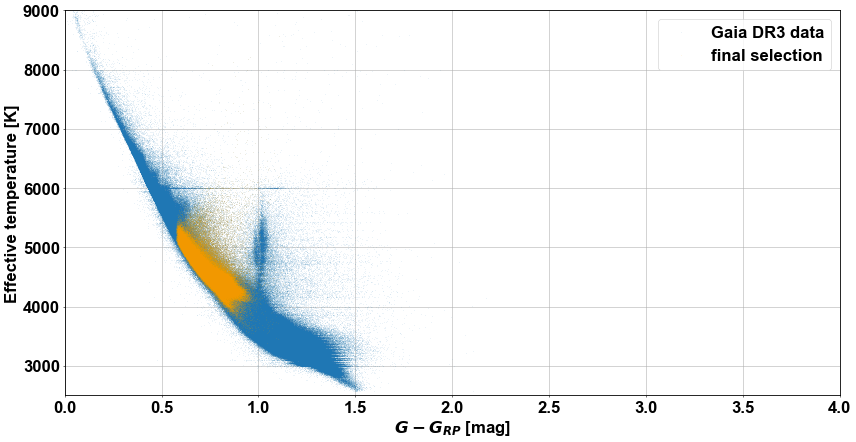

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot(g_rp2, teff2, '.', markersize=1, label='Gaia DR3 data', alpha=0.1)
# ax.plot(bp_rp2[aa&rr], teff2[aa&rr], '.', markersize=1, label='absolut magnitude cut', alpha=0.1)
ax.plot(g_rp2[rr&(absolute_magnitude2>=left)&(absolute_magnitude2<=right)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m3)], teff2[rr&(absolute_magnitude2>=left)&(absolute_magnitude2<=right)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m3)], '.', markersize=1, label='final selection', color='orange', alpha=0.1)
# plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
# plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
# plt.axvline(x=1.2, color='r', linestyle='--', linewidth=2, label='1.2')
# plt.axvline(x=1.8, color='r', linestyle='--', linewidth=2, label='1.8')
# plt.axvline(x=1.0, color='r', linestyle='--', linewidth=2, label='1.0')
# plt.axvline(x=2.0, color='r', linestyle='--', linewidth=2, label='2.0')
ax.set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax.set_ylabel('Effective temperature [K]')
ax.set_ylim(2500, 9000)
ax.set_xlim(0, 4)
plt.grid(which='both')
plt.legend()
plt.savefig('teff_bp_rp.png')
fig.set_dpi(50)
plt.show()

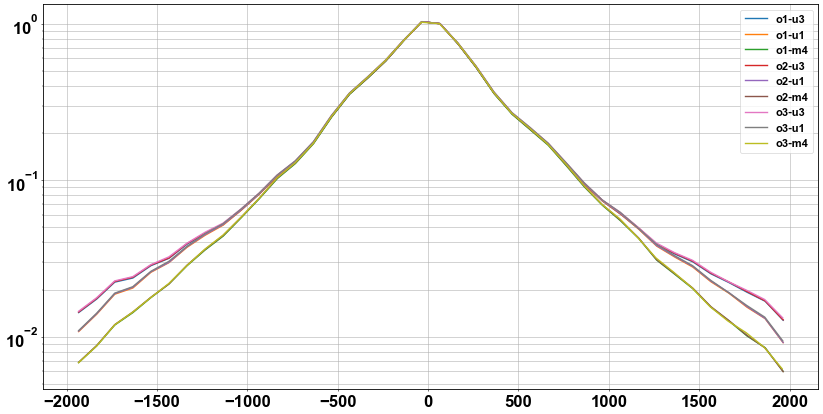

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins35[:-1]+bins35[1:])/2, n35/n35[20], label='o1-u3')
ax.plot((bins33[:-1]+bins33[1:])/2, n33/n33[20], label='o1-u1')
ax.plot((bins48[:-1]+bins48[1:])/2, n48/n48[20], label='o1-m4')
ax.plot((bins39[:-1]+bins39[1:])/2, n39/n39[20], label='o2-u3')
ax.plot((bins37[:-1]+bins37[1:])/2, n37/n37[20], label='o2-u1')
ax.plot((bins50[:-1]+bins50[1:])/2, n50/n50[20], label='o2-m4')
ax.plot((bins43[:-1]+bins43[1:])/2, n43/n43[20], label='o3-u3')
ax.plot((bins41[:-1]+bins41[1:])/2, n41/n41[20], label='o3-u1')
ax.plot((bins51[:-1]+bins51[1:])/2, n51/n51[20], label='o3-m4')


ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
plt.savefig('selections2.png')
fig.set_dpi(50)
plt.show()

240391
235146


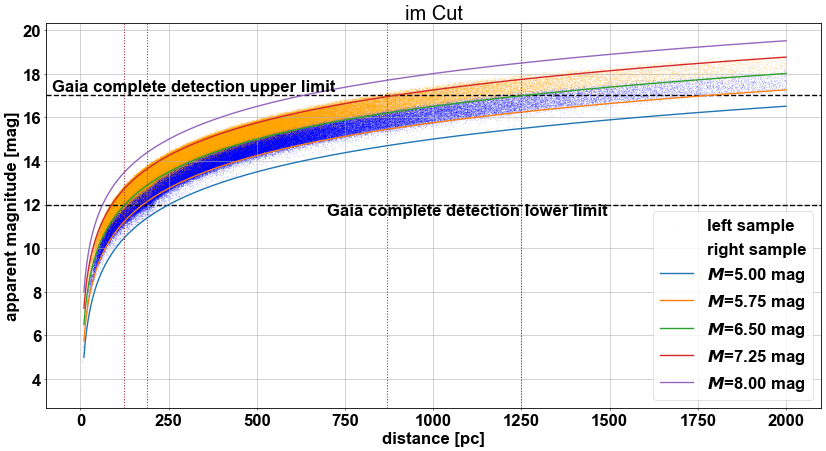

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]

ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)
cut = r&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)
sampleleft = (absolute_magnitude2>=left) & (absolute_magnitude2<=middle)
sampleright = (absolute_magnitude2>=middle) & (absolute_magnitude2<=right)
scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleleft]), apparent_magnitude2[cut&sampleleft], marker='.', c='blue', s=0.1, label='left sample', alpha=0.5)
scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleright]), apparent_magnitude2[cut&sampleright], marker='.', c='orange', s=0.1, label='right sample', alpha=0.5)
print(len(np.abs(dist_pc2[cut&sampleright])))
print(len(np.abs(dist_pc2[cut&sampleleft])))
z = np.linspace(0, 2000, 100)
Ms = np.linspace(5.0, 8.0, 5) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2f} mag".format(M))
plt.text(-80, 17.2, "Gaia complete detection upper limit")
plt.text(700, 11.5, "Gaia complete detection lower limit")
ax[0].grid()
ax[0].legend(loc='lower right')
ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
ax[0].set_title('im Cut')

ax[0].axvline(x=190, color='brown', linestyle=':', linewidth=1.5)
ax[0].axvline(x=125, color='brown', linestyle=':', linewidth=1.5)
ax[0].axvline(x=870, color='brown', linestyle=':', linewidth=1.5)
# ax[0].axvline(x=950, color='brown', linestyle=':', linewidth=1)
ax[0].axvline(x=1250, color='brown', linestyle=':', linewidth=1.5)
# ax[0].axvline(x=1400, color='brown', linestyle=':', linewidth=1)
# ax[0].axvline(x=1600, color='brown', linestyle=':', linewidth=1)

plt.savefig('absmag_dist.png')
fig.set_dpi(50)
plt.show()